# Exact bispectrum shapes: a first look

This notebook uses the two modules of this repository, the companion code of [arXiv:2609.38167](https://arxiv.org/abs/2609.38167), `ec_kernels.py` and `ec_shapes.py`, to draw three things: one shape over all triangles, the isosceles cut down to the squeezed limit, and the equilateral amplitudes of the six channels along λ at fixed μ<sub>eff</sub>. It ends with one check against a known limit. It runs in under a minute with `numpy`, `scipy`, `mpmath` and `matplotlib`; start it from the repository's folder so that the two modules are found.

The shape is S = (k<sub>1</sub>k<sub>2</sub>k<sub>3</sub>)² B<sub>ζ</sub> / [(2π)⁴ Δ<sub>ζ</sub>⁴]. `reduced_shapes` returns Ŝ<sup>(n)</sup> = S<sup>(n)</sup> Δ<sub>ζ</sub>/c<sub>n</sub>, the shape per unit dimensionless coupling c<sub>n</sub>, for the channels `'0'`, `'1par'`, `'1perp'`, `'2'` and `'3'`; the boost-invariant combination is (LI) = (1⊥) − (1∥). The couplings are listed in the README.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ec_shapes import get_table, reduced_shapes, triangle_grid

plt.rcParams.update({'figure.dpi': 110})
DZ = np.sqrt(2.100549e-9)          # Delta_zeta, the amplitude of the power spectrum, as in the explorer
LAM, MU_EFF = 2.0, 2.0             # the mixing lambda = rho/H and the collider frequency mu_eff
NAME = {'0': '(0)', '1par': r'(1$\parallel$)', '1perp': r'(1$\perp$)', 'LI': '(LI)', '2': '(2)', '3': '(3)'}

def shapes(T, k1, k2, k3):
    '''Reduced shapes of the six channels: the five computed ones plus LI = (1perp) - (1par).'''
    S = reduced_shapes(T, k1, k2, k3)
    S['LI'] = S['1perp'] - S['1par']
    return S

T = get_table(LAM, MU_EFF)         # tabulates the dressed leg kernels at this point, in a fraction of a second
S11 = shapes(T, [1.0], [1.0], [1.0])   # the equilateral values, used to normalise
print('lambda = %g, mu_eff = %g:  m^2/H^2 = %.2f,  R = %.4f' % (LAM, MU_EFF, MU_EFF**2 + 9/4 - LAM**2, T.R))

lambda = 2, mu_eff = 2:  m^2/H^2 = 2.25,  R = 2.8601


## One shape over all triangles

x = k<sub>1</sub>/k<sub>3</sub> and y = k<sub>2</sub>/k<sub>3</sub> with |1 − y| ≤ x ≤ y ≤ 1: the equilateral point is the top-right corner, the squeezed limit the top-left corner, and the flattened triangles the lower-left edge x + y = 1. Change `CH` to see another channel.

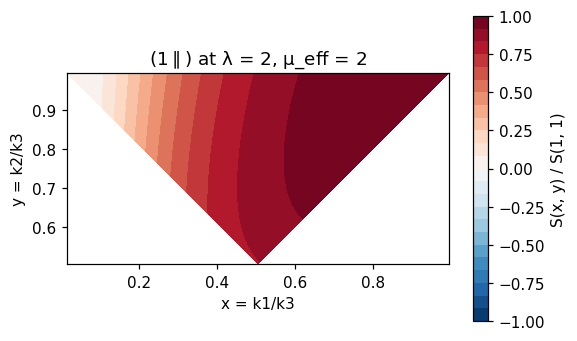

In [2]:
CH = '1par'                       # any of '0', '1par', '1perp', 'LI', '2', '3'
x, y = triangle_grid(0.01)
S = shapes(T, x, y, np.ones_like(x))[CH] / S11[CH][0]
m = np.max(np.abs(S))
fig, ax = plt.subplots(figsize=(5.6, 3.6))
c = ax.tricontourf(x, y, S, levels=np.linspace(-m, m, 25), cmap='RdBu_r')
fig.colorbar(c, ax=ax, label='S(x, y) / S(1, 1)')
ax.set(xlabel='x = k1/k3', ylabel='y = k2/k3', aspect='equal', title='%s at λ = %g, μ_eff = %g' % (NAME[CH], LAM, MU_EFF))
plt.show()

## The isosceles cut and the squeezed limit

S(κ, 1, 1)/S(1, 1, 1) with κ = k<sub>1</sub>/k<sub>3</sub>, from the equilateral point (κ = 1) deep into the squeezed limit. Dividing by κ<sup>1/2</sup> gives the collider oscillations, periodic in ln κ at the frequency μ<sub>eff</sub>, a constant amplitude as κ → 0.

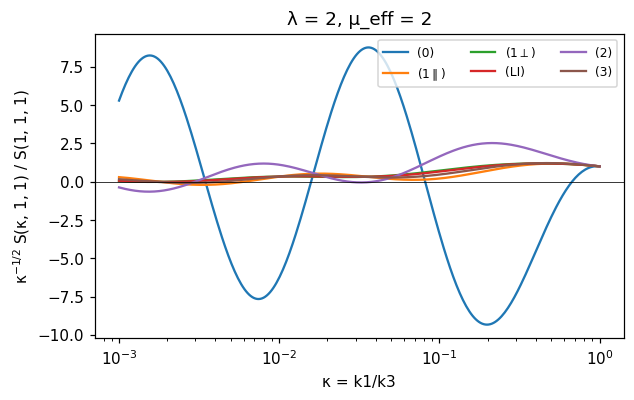

In [3]:
kappa = np.geomspace(1e-3, 1.0, 300)
Siso = shapes(T, kappa, np.ones_like(kappa), np.ones_like(kappa))
fig, ax = plt.subplots(figsize=(6.2, 3.6))
for ch in NAME:
    ax.semilogx(kappa, Siso[ch] / S11[ch][0] / np.sqrt(kappa), label=NAME[ch])
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='κ = k1/k3', ylabel='κ$^{-1/2}$ S(κ, 1, 1) / S(1, 1, 1)', title='λ = %g, μ_eff = %g' % (LAM, MU_EFF))
ax.legend(ncol=3, fontsize=8)
plt.show()

## Equilateral amplitudes along λ at fixed μ<sub>eff</sub>

f<sub>NL</sub><sup>(n)</sup>/c<sub>n</sub> = (10/9) Ŝ<sup>(n)</sup>(k, k, k)/Δ<sub>ζ</sub>, the equilateral amplitude per unit coupling, for λ from 0.1 to 6 at μ<sub>eff</sub> = 2; dashed where it is negative. (1⊥) and (LI) have no free coupling: the boosts fix H/Λ<sub>1</sub> = 2πΔ<sub>ζ</sub>λ/√R.

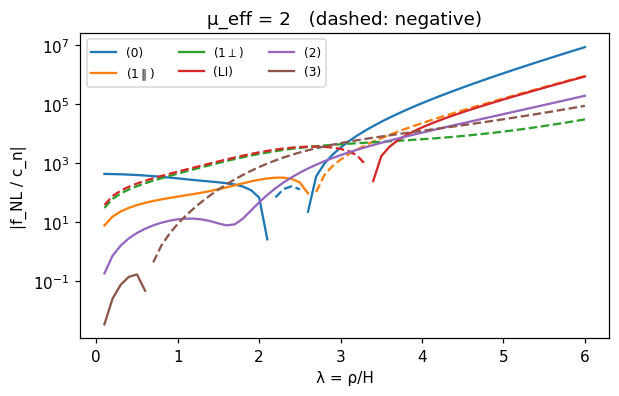

In [4]:
MU_SCAN = 2.0
lams = np.linspace(0.1, 6.0, 60)
fnl = {ch: np.empty(len(lams)) for ch in NAME}
for i, lam in enumerate(lams):
    Se = shapes(get_table(lam, MU_SCAN), [1.0], [1.0], [1.0])
    for ch in NAME:
        fnl[ch][i] = (10 / 9) * Se[ch][0] / DZ
fig, ax = plt.subplots(figsize=(6.2, 3.6))
for ch in NAME:
    f = fnl[ch]
    line, = ax.semilogy(lams, np.where(f > 0, f, np.nan), label=NAME[ch])
    ax.semilogy(lams, np.where(f < 0, -f, np.nan), '--', color=line.get_color())
ax.set(xlabel='λ = ρ/H', ylabel='|f_NL / c_n|', title='μ_eff = %g   (dashed: negative)' % MU_SCAN)
ax.legend(ncol=3, fontsize=8)
plt.show()

## A check

At weak mixing the no-exchange channel reduces to the single-field vertex π̇<sub>c</sub>³, whose equilateral amplitude is f<sub>NL</sub><sup>(0)</sup>/c<sub>0</sub> → 5/(81π Δ<sub>ζ</sub>) ≈ 4.3 × 10² as λ → 0.

In [5]:
target = 5 / (81 * np.pi * DZ)
for lam in (0.1, 0.03, 0.01):
    f0 = (10 / 9) * shapes(get_table(lam, MU_SCAN), [1.0], [1.0], [1.0])['0'][0] / DZ
    print('lambda = %-5g  f_NL/c_0 = %8.3f   ratio to 5/(81 pi Delta_zeta) = %.6f' % (lam, f0, f0 / target))

lambda = 0.1    f_NL/c_0 =  427.190   ratio to 5/(81 pi Delta_zeta) = 0.996442
lambda = 0.03   f_NL/c_0 =  428.578   ratio to 5/(81 pi Delta_zeta) = 0.999679
lambda = 0.01   f_NL/c_0 =  428.700   ratio to 5/(81 pi Delta_zeta) = 0.999964


The explorer draws the same shapes in the browser, over all triangles and at any point of the plane: <https://lucaspinolcnrs.github.io/exact-collider/>.